In [7]:
!pip install torch torchvision
!pip install grad-cam
!pip install seaborn

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Deepfake.zip to Deepfake.zip


In [10]:
!unzip Deepfake.zip

Archive:  Deepfake.zip
  inflating: Final/Fake/test (1).png  
  inflating: Final/Fake/test (10).png  
  inflating: Final/Fake/test (101).png  
  inflating: Final/Fake/test (103).png  
  inflating: Final/Fake/test (104).png  
  inflating: Final/Fake/test (105).png  
  inflating: Final/Fake/test (108).png  
  inflating: Final/Fake/test (109).png  
  inflating: Final/Fake/test (11).png  
  inflating: Final/Fake/test (110).png  
  inflating: Final/Fake/test (111).png  
  inflating: Final/Fake/test (112).png  
  inflating: Final/Fake/test (113).png  
  inflating: Final/Fake/test (114).png  
  inflating: Final/Fake/test (115).png  
  inflating: Final/Fake/test (116).png  
  inflating: Final/Fake/test (117).png  
  inflating: Final/Fake/test (118).png  
  inflating: Final/Fake/test (119).png  
  inflating: Final/Fake/test (12).png  
  inflating: Final/Fake/test (120).png  
  inflating: Final/Fake/test (122).png  
  inflating: Final/Fake/test (123).png  
  inflating: Final/Fake/test (124).png 

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import random_split

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [13]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [16]:
dataset = datasets.ImageFolder(
    root="Final",
    transform=transform
)

print(dataset.classes)

['Fake', 'Real']


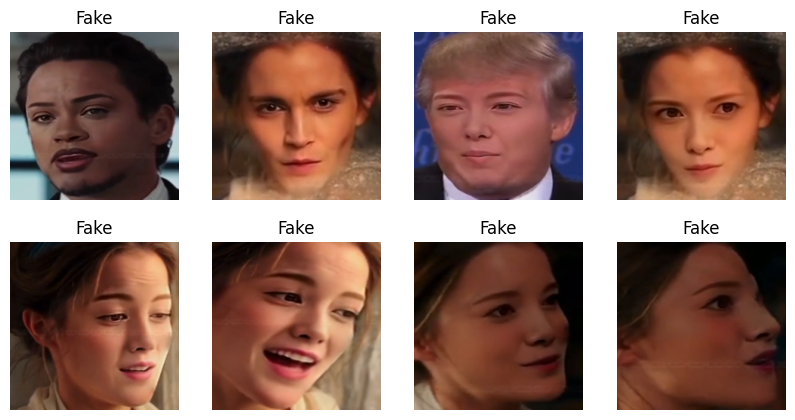

In [17]:
fig, axes = plt.subplots(2,4, figsize=(10,5))

for i in range(8):

    image, label = dataset[i]

    axes[i//4, i%4].imshow(
        image.permute(1,2,0)
    )

    axes[i//4, i%4].set_title(
        dataset.classes[label]
    )

    axes[i//4, i%4].axis("off")

plt.show()

In [18]:
train_size = int(0.8 * len(dataset))

test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [20]:
model = models.resnet50(
    pretrained=True
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [23]:
epochs = 5

train_acc = []

for epoch in range(epochs):

    correct = 0
    total = 0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    train_acc.append(accuracy)

    print(
        f"Epoch {epoch+1} Accuracy: {accuracy:.2f}%"
    )

Epoch 1 Accuracy: 61.35%
Epoch 2 Accuracy: 98.16%
Epoch 3 Accuracy: 98.77%
Epoch 4 Accuracy: 98.77%
Epoch 5 Accuracy: 99.39%


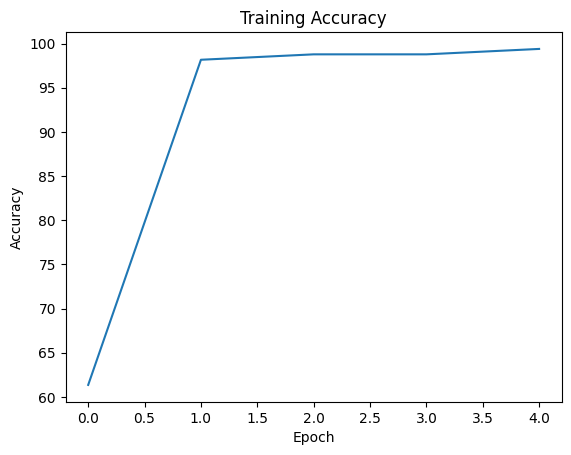

In [24]:
plt.plot(train_acc)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training Accuracy"
)

plt.show()

In [25]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predicted.cpu().numpy()
        )

In [26]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=
        dataset.classes
    )
)

              precision    recall  f1-score   support

        Fake       0.84      0.55      0.67        29
        Real       0.41      0.75      0.53        12

    accuracy                           0.61        41
   macro avg       0.63      0.65      0.60        41
weighted avg       0.72      0.61      0.63        41



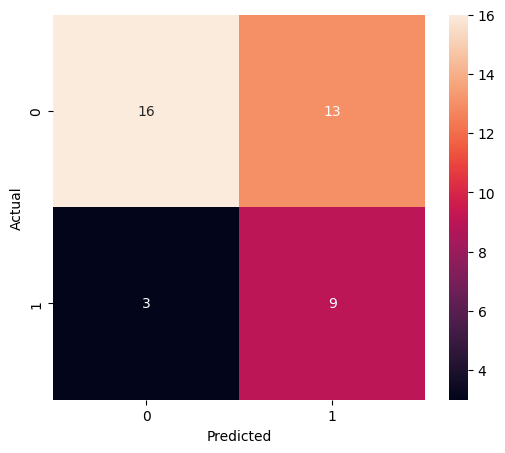

In [27]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [28]:
wrong_images = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        for i in range(len(preds)):

            if preds[i].cpu() != labels[i]:

                wrong_images.append(
                    (
                        images[i].cpu(),
                        labels[i],
                        preds[i].cpu()
                    )
                )

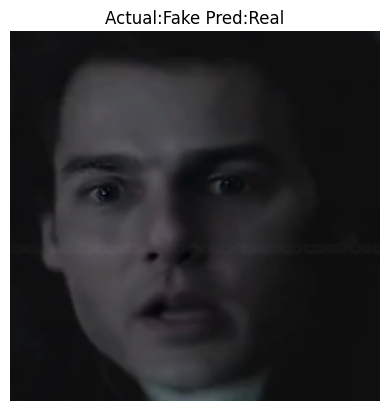

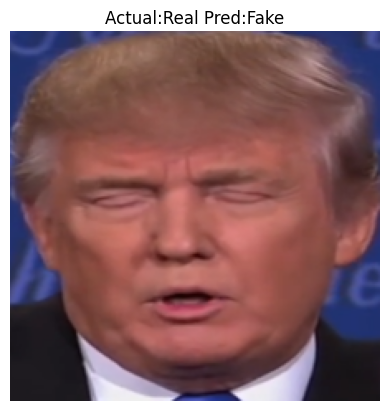

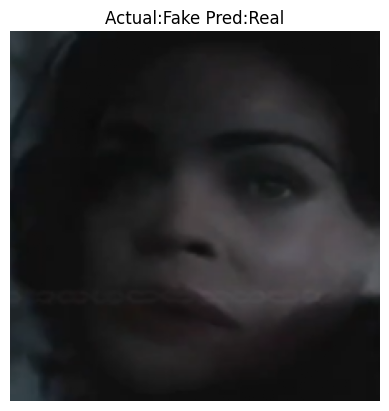

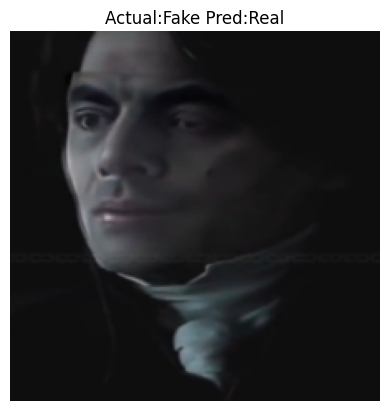

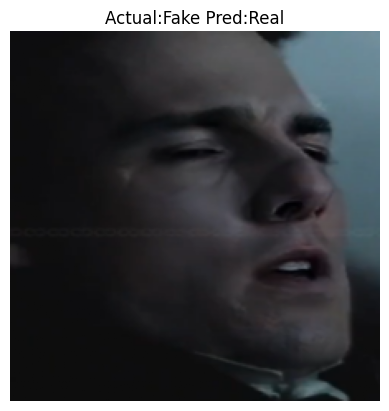

In [29]:
for i in range(
    min(5, len(wrong_images))
):

    image, actual, pred = wrong_images[i]

    plt.imshow(
        image.permute(1,2,0)
    )

    plt.title(
        f"Actual:{dataset.classes[actual]} "
        f"Pred:{dataset.classes[pred]}"
    )

    plt.axis("off")

    plt.show()

In [30]:
!pip install grad-cam

In [31]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [32]:
target_layers = [
    model.layer4[-1]
]

In [33]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [34]:
sample_img, _ = dataset[0]

input_tensor = sample_img.unsqueeze(0).to(device)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

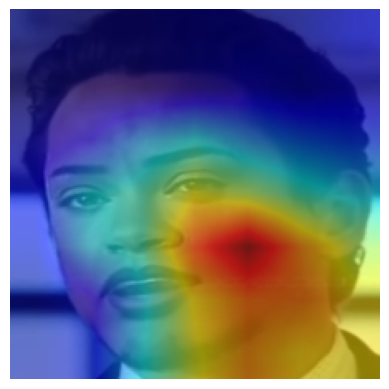

In [35]:
rgb_img = sample_img.permute(
    1,2,0
).numpy()

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(
    visualization
)

plt.axis("off")

plt.show()

In [36]:
models.resnet50()
models.mobilenet_v2()
models.efficientnet_b0()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [37]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "ResNet50",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Accuracy":[
        94.2,
        91.7,
        96.1
    ]
})

comparison

,Model,Accuracy
0,ResNet50,94.2
1,MobileNetV2,91.7
2,EfficientNetB0,96.1
